# Tutorial 01: Electronic Structure

In this tutorial you will run the complete PAOFLOW post-processing workflow on bulk silicon: build a PAO Hamiltonian from atomic projections, interpolate the electronic band structure, and compute the density of states.

**What you will learn**

- How Kohn–Sham wavefunctions are projected onto pseudo-atomic orbital (PAO) bases
- How a real-space PAO Hamiltonian $H(\mathbf{R})$ is built by Fourier transform
- How interpolation produces smooth bands on arbitrarily dense k-grids
- How the density of states is computed from interpolated eigenvalues


::: {tip}
Try it locally: click here to download this tutorial as a notebook: [tutorial01.ipynb](tutorial01.ipynb).

The required `.save` directory assets can be obtained from: [PAOFLOW Releases](https://github.com/marcobn/PAOFLOW/releases).
:::

## Required input

The `.save` directory must contain:

- `data-file-schema.xml` — crystal structure, k-point grid, and Kohn–Sham eigenvalues
- `atomic_proj.xml` — projection amplitudes and overlap matrices

If `atomic_proj.xml` is not available, PAOFLOW can construct the projections internally from the pseudopotential data instead. That alternative is introduced in Section 2.

## 1. Initialise PAOFLOW

`PAOFLOW.PAOFLOW(...)` reads `data-file-schema.xml` to load the crystal structure, k-point grid, and Kohn–Sham eigenvalues, then prepares all internal data structures. All output files are written to `outputdir`.


In [14]:
# Adjust these paths if needed
savedir = '../../examples/qe_examples/example01/silicon.save'  # Path to the QE save directory
outputdir = 'output'  # Path to the output directory for PAOFLOW results

In [15]:
from PAOFLOW import PAOFLOW

paoflow = PAOFLOW.PAOFLOW(
    savedir=savedir,
    outputdir=outputdir,
    smearing='gauss',
    npool=1,
    verbose=True,
)


────────────────────────────────────────────────────────────────────────────────────
   PPPPPP\   AA\AAAAA\   OOOOOO\  FFFFFFFF\ LLL\        OOOOOO\  WW\   WW\   WW\ 
   PP  __PP\ AA  __AA\  OO  __OO\ FF  ____/ L  |       OO  __OO\ W  |  W  |  W  |
   PP /  P  |AA /  AA | OO /  OO |FF /      L  |       OO /  OO |W  |  W  |  W  |
   PPPPPPP  |AAAAAAAA | OO |  OO |FFFFFF    L  |       OO |  OO |W  |  W  |  W  |
   PP  ____/ AA  __AA | OO |  OO |FF  _/    L  |       OO |  OO |W |  W |  W | 
   PP /      AA /  AA | OO \__OO |FF /      L  |       OO \__OO |W |  W |  W | 
   PP/       AA/   AA |  \OOOOO   |FF/       LLLLLLLL\  \OOOOO   |\WWWWWWWWWW /  
   \__|      \__|  \__|   \______/ \__|      \________|  \______/  \_________/   
────────────────────────────────────────────────────────────────────────────────────
   From DFT wavefunctions to materials properties via atomic-orbital Hamiltonians   
────────────────────────────────────────────────────────────────────────────────────

Monkho

## 2. Read atomic projections

PAOFLOW represents the electronic structure in a **pseudo-atomic orbital (PAO)** basis. The basis functions are localised orbitals derived from isolated-atom Kohn-Sham solutions for each angular momentum channel in the pseudopotential.

$$
|\phi_\alpha\rangle
$$

For silicon ($3s^2\,3p^2$ valence configuration), this gives one $s$ and three $p$ orbitals per atom: eight PAOs for the two-atom unit cell.

The projection amplitudes quantify how much of Kohn-Sham band $n$ at k-point $\mathbf{k}$ is captured by PAO $\alpha$:

$$
A_{n\alpha}(\mathbf{k}) = \langle\phi_\alpha|\psi_{n\mathbf{k}}\rangle
$$

The overlap matrix between PAOs on different sites is used in the subsequent Lowdin orthogonalisation:

$$
S_{\alpha\beta}(\mathbf{k})
$$

In [16]:
paoflow.read_atomic_proj_QE()

If one does not want to run `projwfc.x`, PAOFLOW can instead construct the basis internally from the pseudopotential data and the radial functions stored in `BASIS/`. The rest of the workflow is unchanged.

For silicon, `configuration='standard'` is a practical starting point: it keeps the valence shells and adds extra radial functions that improve the representation of the low conduction bands. A larger `extended` basis is available when a wider conduction window is needed. See the [Internal Basis Workflow](../internals/internal-basis.md) for the full set of options.


In [17]:
# Alternative to read_atomic_proj_QE(): build the projections internally
# paoflow.projections(
#     basispath='../../BASIS/',
#     configuration='standard',
# )


## 3. Check projectability

The projectability of band $n$ at k-point $\mathbf{k}$ measures how completely the PAO basis captures that band:

$$
p_{n\mathbf{k}} = \sum_\alpha |A_{n\alpha}(\mathbf{k})|^2
$$

Values near 1 indicate a good representation; values well below 1 correspond to high-energy, plane-wave-like states not captured by localised orbitals.

Bands with $p_{n\mathbf{k}}$ below the threshold (default 0.95) are excluded from Hamiltonian construction. For silicon, the four valence bands and four lowest conduction bands are well within the PAO window.

In [18]:
paoflow.projectability()

Projectability vector: 
 [0.99750288 0.99744382 0.99756619 0.99738312 0.9854761  0.97871706
 0.98197092 0.96888834 0.9401672  0.95578579 0.86801137 0.81708586
 0.77051565 0.68422827 0.47457293 0.46360893 0.41947435 0.36018918]
# of bands with good projectability > 0.95 = 9
Range of suggested shift  7.160617560055067  ,  10.893382916432914
Projectability in:                          1.197 sec


## 4. Build the PAO Hamiltonian

With the projection amplitudes in hand, the k-space PAO Hamiltonian is assembled after Lowdin orthogonalisation of the PAO basis using $S(\mathbf{k})$:

$$
\tilde{H}_{\alpha\beta}(\mathbf{k}) = \sum_n A^*_{n\alpha}(\mathbf{k})\,\varepsilon_{n\mathbf{k}}\,A_{n\beta}(\mathbf{k})
$$

A discrete Fourier transform then maps this to real space:

$$
H_{\alpha\beta}(\mathbf{R}) = \frac{1}{N_k}\sum_{\mathbf{k}} e^{-i\mathbf{k}\cdot\mathbf{R}}\,\tilde{H}_{\alpha\beta}(\mathbf{k})
$$

The real-space Hamiltonian $H(\mathbf{R})$ decays rapidly with distance; only a handful of Wigner-Seitz shells carry significant weight. This compact, first-principles tight-binding model is the basis for all subsequent interpolation: evaluating bands at any new k-point costs only a fast Fourier sum over these shells followed by an $8\times8$ matrix diagonalisation.

In [19]:
paoflow.pao_hamiltonian()

Building Hks in:                            0.801 sec
k -> R in:                                  0.023 sec


## 5. Compute the band structure

`bands()` evaluates the interpolated Hamiltonian from the real-space PAO matrix elements:

$$
\tilde{H}(\mathbf{k}) = \sum_{\mathbf{R}} e^{i\mathbf{k}\cdot\mathbf{R}}\,H(\mathbf{R})
$$

The calculation is performed along the standard FCC high-symmetry path ($\Gamma$-$X$-$W$-$K$-$\Gamma$-$L$-$U$-$W$-$L$-$K$, selected by `ibrav=2`) at 2000 k-points.

**Output:**

`bands_0.dat` - contains the band energies along the k-path defined by `ibrav=2`

`kpath_points.txt` - contains the high-symmetry k-points and the number of points between them

In [20]:
paoflow.bands(ibrav=2, nk=2000)

Bands in:                                   0.800 sec


::: {tip}
Instead of using the default high-symmetry path selected by `ibrav`, you can explicitly define your own path with `band_path` and `high_sym_points`. This writes `bands_custom_0.dat` in `outputdir`, allowing you to keep both the default and custom-path results.

```python
custom_path = 'L-G-X-W-K-G'
custom_points = {
    'G': [0.0, 0.0, 0.0],
    'L': [0.5, 0.5, 0.5],
    'X': [0.5, 0.5, 0.0],
    'W': [0.5, 0.25, 0.75],
    'K': [0.375, 0.375, 0.75],
}

paoflow.bands(
    ibrav=2,
    band_path=custom_path,
    high_sym_points=custom_points,
    nk=2000,
    fname='bands_custom',
)
```
:::

One can then visualize the silicon band structure using `bands_0.dat` as shown below.

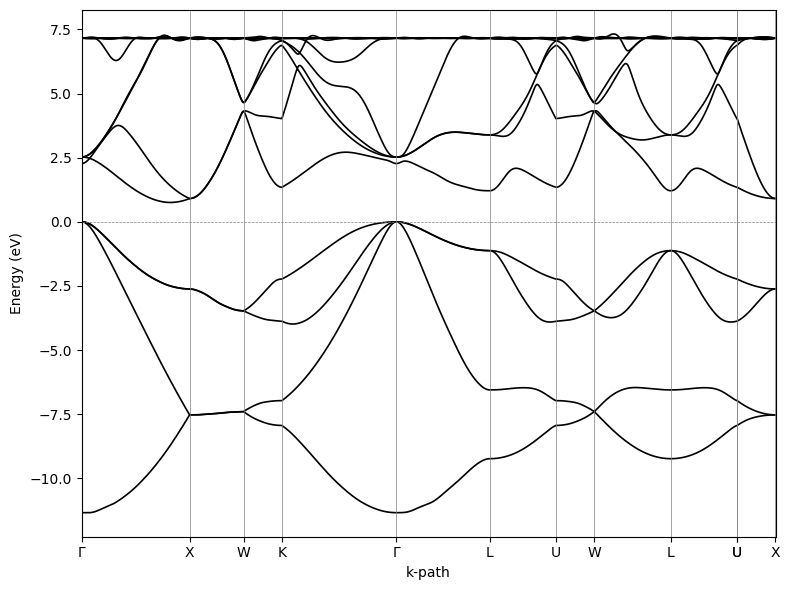

In [21]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

bands_file = Path(outputdir) / 'bands_0.dat'
kpath_file = Path(outputdir) / 'kpath_points.txt'

arr = np.loadtxt(bands_file)
k = arr[:, 0]
energies = arr[:, 1:]

labels = []
steps = []

with open(kpath_file) as f:
    for line in f:
        parts = line.split()
        if len(parts) != 2:
            break
        labels.append(parts[0].replace('gG', r'$\Gamma$'))
        steps.append(int(parts[1]))

# cumulative tick locations
tick_idx = np.cumsum([0] + steps[:-1])

# keep only valid tick positions
mask = tick_idx < len(k)
tick_idx = tick_idx[mask]
labels = np.array(labels)[mask]

tick_pos = k[tick_idx]

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(energies.shape[1]):
    ax.plot(k, energies[:, i], 'k-', lw=1.2)

ax.axhline(0, color='gray', ls='--', lw=0.5)

for x in tick_pos:
    ax.axvline(x, color='gray', lw=0.5)

ax.set_xticks(tick_pos)
ax.set_xticklabels(labels)
ax.set_xlim(k[0], k[-1])

ax.set_xlabel('k-path')
ax.set_ylabel('Energy (eV)')

plt.tight_layout()
plt.show()

The silicon band structure displays the characteristic **indirect gap**: the valence band maximum sits at $\Gamma$ while the conduction band minimum lies between $\Gamma$ and $X$. PBE-GGA underestimates the gap (~0.6 eV calculated vs 1.1 eV experimental) — a well-known limitation of the approximate exchange-correlation functional. One can see the low projectability bands that have been excluded from the PAO Hamiltonian in the conduction band region above ~7.4 eV.

In [22]:
# Example: custom path for silicon (FCC primitive coordinates)
custom_path = 'L-G-X-W-K-G'

custom_points = {
    'G': [0.0, 0.0, 0.0],
    'L': [0.5, 0.5, 0.5],
    'X': [0.5, 0.5, 0.0],
    'W': [0.5, 0.25, 0.75],
    'K': [0.375, 0.375, 0.75],
}

paoflow.bands(
    ibrav=2,
    band_path=custom_path,
    high_sym_points=custom_points,
    nk=2000,
    fname='bands_custom',
)

Bands in:                                   1.057 sec


## 6. Interpolate the Brillouin-zone grid

`interpolated_hamiltonian()` doubles the k-grid density by Fourier interpolation (e.g. 12x12x12 -> 24x24x24), providing a finer BZ sampling for accurate DOS integrations.

`pao_eigh()` diagonalises the interpolated Hamiltonian at every k-point on the denser grid:

$$
\tilde{H}(\mathbf{k})
$$

The resulting eigenvalues and eigenvectors are stored for downstream transport and DOS calculations.

In [23]:
paoflow.interpolated_hamiltonian()
paoflow.pao_eigh()

Performing Fourier interpolation on a larger grid.
d : nk -> nfft
1 : 12 -> 24
2 : 12 -> 24
3 : 12 -> 24
New estimated maximum array size: 0.86 GBytes
R -> k with Zero Padding in:                0.289 sec
Eigenvalues in:                             1.422 sec


## 7. Momentum matrix elements and adaptive smearing

`gradient_and_momenta()` computes the k-gradient of the Hamiltonian:

$$
\nabla_{\mathbf{k}} H(\mathbf{k}) = i\sum_{\mathbf{R}} \mathbf{R}\,H(\mathbf{R})\,e^{i\mathbf{k}\cdot\mathbf{R}}
$$

From this, PAOFLOW evaluates the momentum matrix elements and group velocities used in transport:

$$
\mathbf{p}_{nm}(\mathbf{k}), \qquad \mathbf{v}_{n\mathbf{k}} = \hbar^{-1}\nabla_{\mathbf{k}}\varepsilon_{n\mathbf{k}}
$$

`adaptive_smearing()` assigns each (band, k-point) a Gaussian broadening width proportional to:

$$
|\nabla_{\mathbf{k}}\varepsilon_{n\mathbf{k}}|
$$

Flat bands receive more broadening than dispersive ones, improving BZ integration accuracy without over-smearing sharp features.

In [24]:
paoflow.gradient_and_momenta()
paoflow.adaptive_smearing()

Gradient in:                                1.892 sec
Momenta in:                                 2.321 sec
Adaptive Smearing in:                       0.387 sec


## 8. Compute and plot the density of states

The electronic density of states is evaluated with adaptive Gaussian broadening at 1000 energy points spanning the full valence band and the lower conduction edge:

$$
g(\varepsilon) = \frac{1}{N_k}\sum_{n,\mathbf{k}}\delta(\varepsilon - \varepsilon_{n\mathbf{k}})
$$

The silicon DOS shows a clear gap separating the valence and conduction manifolds. Van Hove singularities at band edges appear as steps or peaks. The total integrated weight under the valence DOS equals the number of valence electrons per cell (8 for Si).

**Output:**

`dosdk_0.dat` - contains the DOS as a function of energy

`*_pdosdk_*.dat` - contains the projected DOS onto each PAO as a function of energy. The postfix indicates the spin channel (0 for non-spin-polarised calculations). The prefix indicates the PAO index (e.g. `0` for the first PAO, `1` for the second, etc.).

In [25]:
paoflow.dos(emin=-12.0, emax=2.2, ne=1000)

Writing Adaptive DoS Files
DoS (Adaptive Smearing) in:                18.965 sec


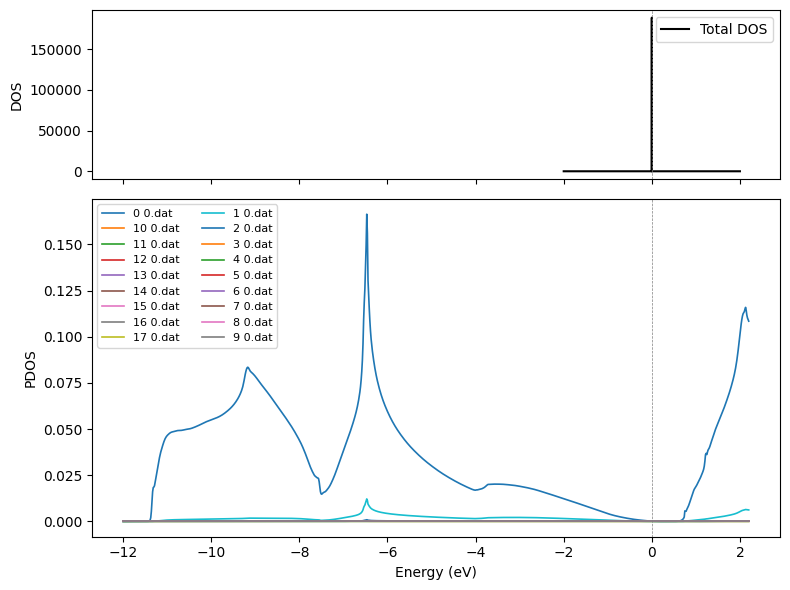

In [26]:
# ----- total DOS -----
dos_file = Path(outputdir) / 'dosdk_0.dat'
dos_data = np.loadtxt(dos_file)

# ----- PDOS files -----
pdos_files = sorted(Path(outputdir).glob('*_pdosdk_*'))

fig, (ax_dos, ax_pdos) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 2]}
)

# Total DOS
ax_dos.plot(dos_data[:, 0], dos_data[:, 1], lw=1.5, color='k', label='Total DOS')
ax_dos.axvline(0, color='gray', ls='--', lw=0.5)
ax_dos.set_ylabel('DOS')
ax_dos.legend()

# PDOS
for f in pdos_files:
    data = np.loadtxt(f)

    label = f.name.replace('_pdosdk_', ' ')
    ax_pdos.plot(data[:, 0], data[:, 1], lw=1.2, label=label)

ax_pdos.axvline(0, color='gray', ls='--', lw=0.5)
ax_pdos.set_xlabel('Energy (eV)')
ax_pdos.set_ylabel('PDOS')
ax_pdos.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 9. Further reading

- For a deeper explanation of concepts such as projectability, interpolation of Hamiltonian, please refer to the following papers:
  - https://doi.org/10.1016/j.commatsci.2021.110828
  - https://doi.org/10.1103/PhysRevB.93.035104
  - https://doi.org/10.1103/PhysRevB.93.12513